# Team Pace Comparison
Rank team's race pace from the fastest to the slowest.


In [1]:
import seaborn as sns
from matplotlib import pyplot as plt

import fastf1
import fastf1.plotting


# Load FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=False, color_scheme='fastf1')

Load the race session.
Pick all quick laps (within 107% of fastest lap).
For races with mixed conditions, pick_wo_box() is better.



In [2]:
race = fastf1.get_session(2024, 1, 'R')
race.load()
laps = race.laps.pick_quicklaps()

req         WARNING 	DEFAULT CACHE ENABLED! (53.35 MB) C:\Users\poliz\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching trac

Convert the lap time column from timedelta to integer.
This is a seaborn-specific modification.
If plotting with matplotlib, set mpl_timedelta_support to true
with plotting.setup_mpl.



In [4]:
transformed_laps = laps.copy()
transformed_laps.loc[:, "LapTime (s)"] = laps["LapTime"].dt.total_seconds()
print(transformed_laps)

# order the team from the fastest (lowest median lap time) tp slower
team_order = (
    transformed_laps[["Team", "LapTime (s)"]]
    .groupby("Team")
    .median()["LapTime (s)"]
    .sort_values()
    .index
)
print(team_order)

# make a color palette associating team names to hex codes
team_palette = {team: fastf1.plotting.get_team_color(team, session=race)
                for team in team_order}

                       Time Driver DriverNumber                LapTime  \
0    0 days 01:01:37.489000    VER            1 0 days 00:01:37.284000   
1    0 days 01:03:13.785000    VER            1 0 days 00:01:36.296000   
2    0 days 01:04:50.538000    VER            1 0 days 00:01:36.753000   
3    0 days 01:06:27.185000    VER            1 0 days 00:01:36.647000   
4    0 days 01:08:04.358000    VER            1 0 days 00:01:37.173000   
...                     ...    ...          ...                    ...   
1123 0 days 02:24:01.863000    SAR            2 0 days 00:01:35.660000   
1124 0 days 02:25:37.835000    SAR            2 0 days 00:01:35.972000   
1125 0 days 02:27:13.822000    SAR            2 0 days 00:01:35.987000   
1126 0 days 02:28:49.910000    SAR            2 0 days 00:01:36.088000   
1128 0 days 02:32:05.733000    SAR            2 0 days 00:01:36.209000   

      LapNumber  Stint PitOutTime PitInTime            Sector1Time  \
0           1.0    1.0        NaT       N

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight light, now using 400.


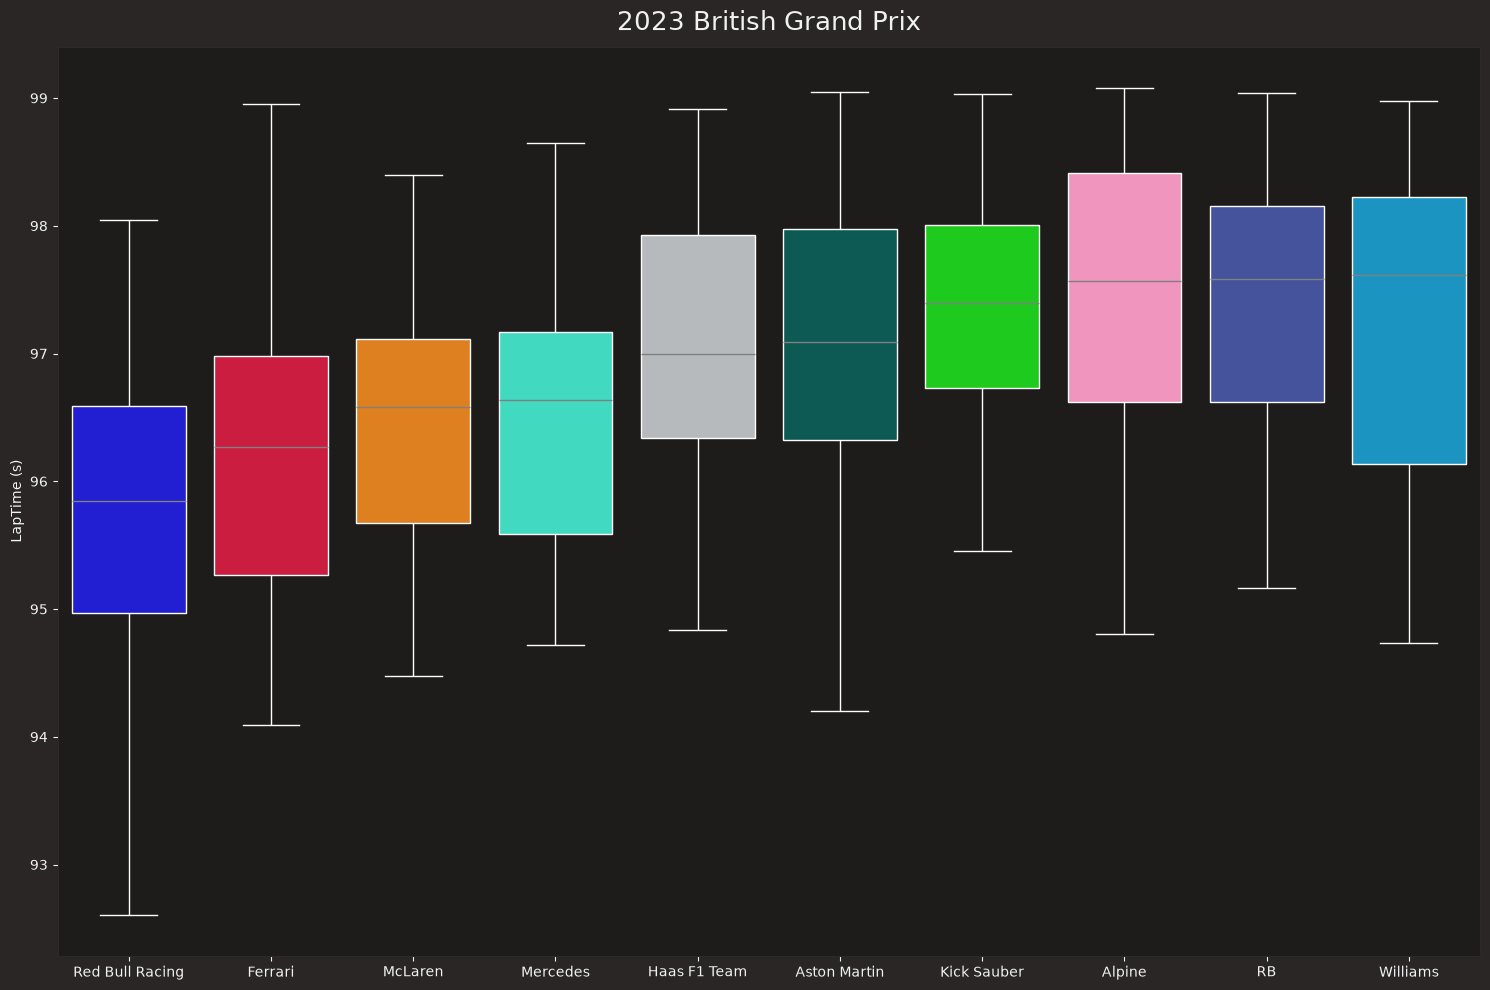

In [5]:
fig, ax = plt.subplots(figsize=(15, 10))
sns.boxplot(
    data=transformed_laps,
    x="Team",
    y="LapTime (s)",
    hue="Team",
    order=team_order,
    palette=team_palette,
    whiskerprops=dict(color="white"),
    boxprops=dict(edgecolor="white"),
    medianprops=dict(color="grey"),
    capprops=dict(color="white"),
)

plt.title("2023 British Grand Prix")
plt.grid(visible=False)

# x-label is redundant
ax.set(xlabel=None)
plt.tight_layout()
plt.show()